# E-commerce Conversion Prediction
## Notebook 1: Exploratory Data Analysis

**Dataset:** UCI Online Shoppers Purchasing Intention (12,330 sessions, 18 features)  
**Goal:** Understand session behavior patterns that drive purchase conversion

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14

print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [2]:
df = pd.read_csv('../data/raw/online_shoppers_intention.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [4]:
print('Missing values:')
print(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')

Missing values:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

Duplicate rows: 125


In [5]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


## 2. Target Variable — Class Imbalance

Revenue (Conversion) Distribution:
         Count  Percentage
Revenue                   
False    10422       84.53
True      1908       15.47


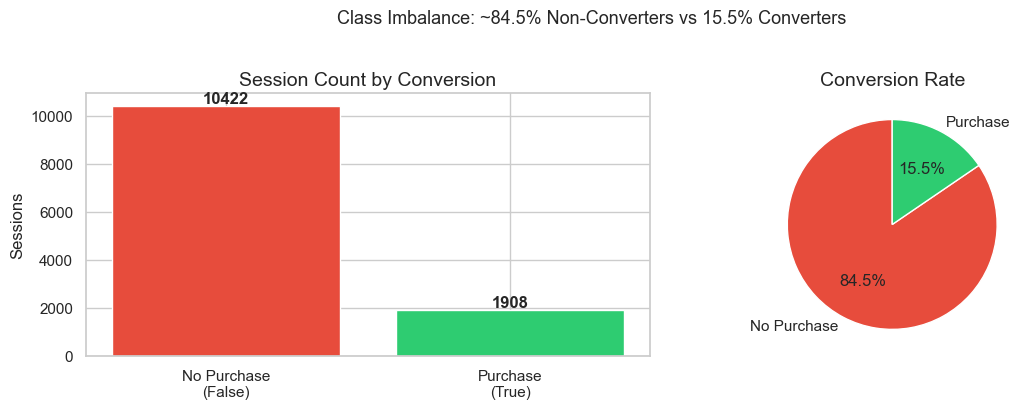

In [6]:
target_counts = df['Revenue'].value_counts()
target_pct = df['Revenue'].value_counts(normalize=True) * 100

print('Revenue (Conversion) Distribution:')
print(pd.DataFrame({'Count': target_counts, 'Percentage': target_pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['No Purchase\n(False)', 'Purchase\n(True)'],
            target_counts.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[0].set_title('Session Count by Conversion')
axes[0].set_ylabel('Sessions')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

axes[1].pie(target_counts.values, labels=['No Purchase', 'Purchase'],
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'],
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Conversion Rate')

plt.suptitle('Class Imbalance: ~84.5% Non-Converters vs 15.5% Converters', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/fig_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Numerical Feature Distributions

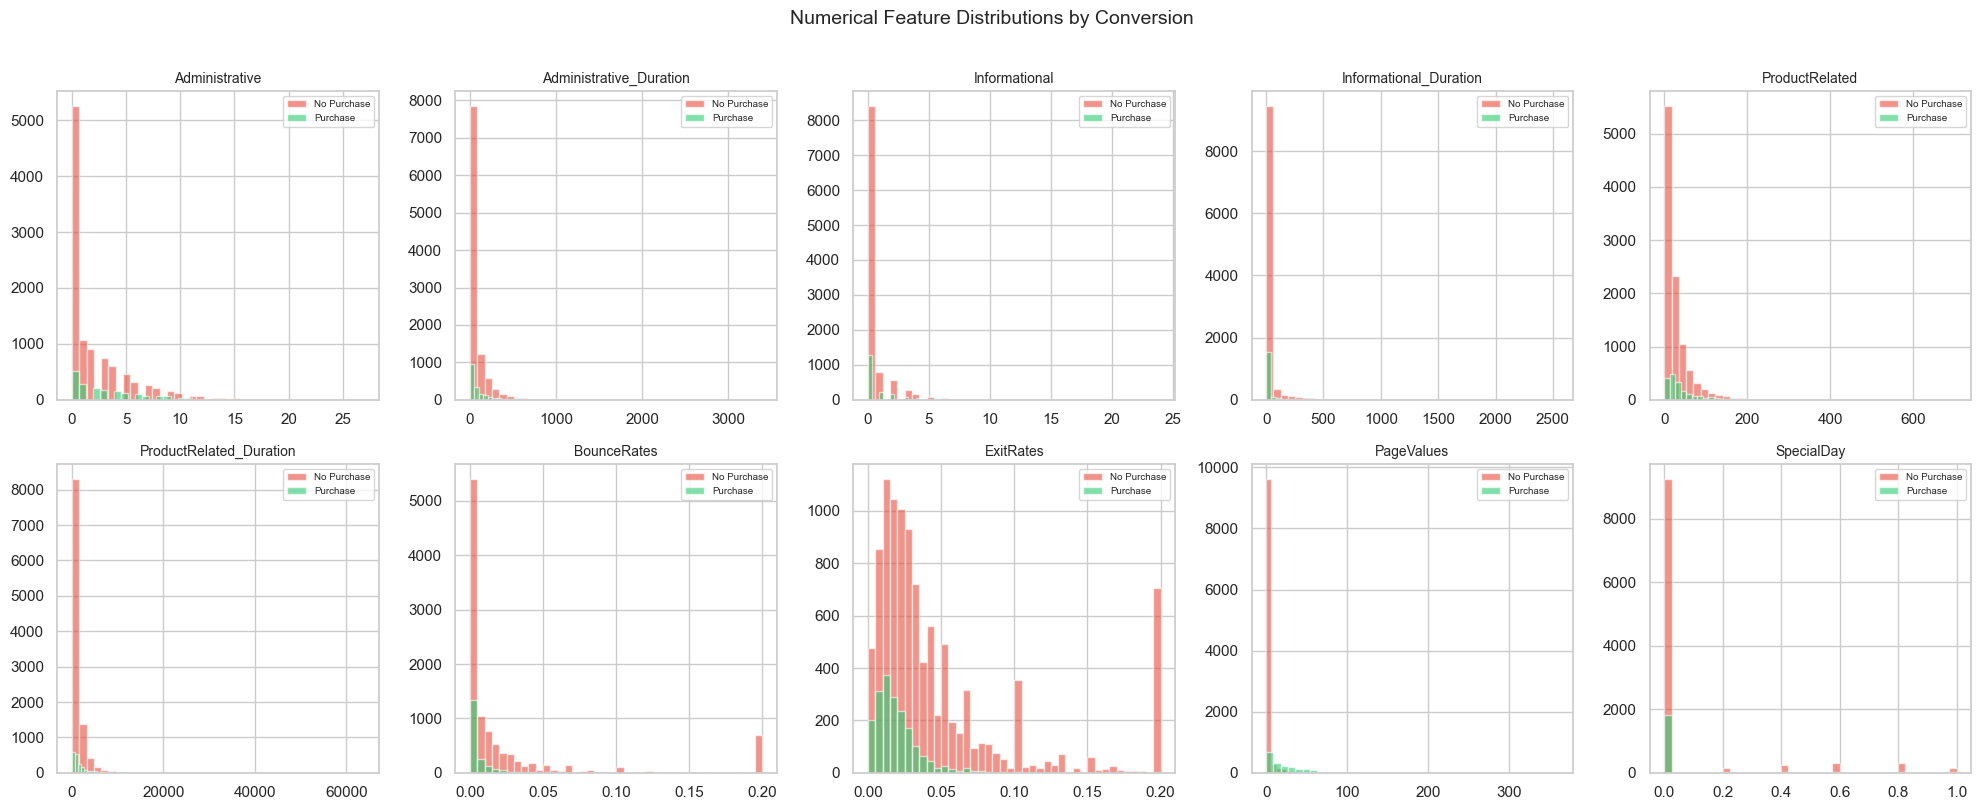

In [7]:
num_cols = ['Administrative', 'Administrative_Duration',
            'Informational', 'Informational_Duration',
            'ProductRelated', 'ProductRelated_Duration',
            'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[df['Revenue'] == False][col], bins=40, alpha=0.6, color='#e74c3c', label='No Purchase')
    axes[i].hist(df[df['Revenue'] == True][col], bins=40, alpha=0.6, color='#2ecc71', label='Purchase')
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=7)

plt.suptitle('Numerical Feature Distributions by Conversion', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/fig_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Conversion Rate by Categorical Features

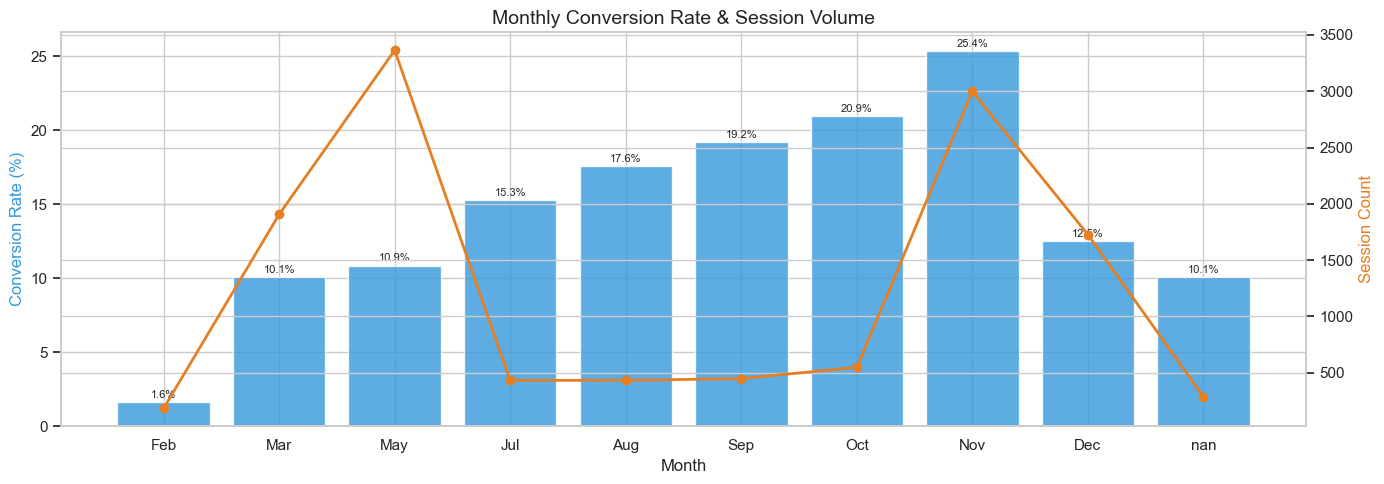

In [8]:
# Conversion by Month
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

month_cvr = df.groupby('Month')['Revenue'].agg(['mean', 'count']).reset_index()
month_cvr.columns = ['Month', 'ConversionRate', 'Sessions']
month_cvr['Month'] = pd.Categorical(month_cvr['Month'], categories=month_order, ordered=True)
month_cvr = month_cvr.sort_values('Month').reset_index(drop=True)
x_labels = month_cvr['Month'].astype(str).tolist()
x_pos = range(len(x_labels))

fig, ax1 = plt.subplots(figsize=(14, 5))
bars = ax1.bar(x_pos, month_cvr['ConversionRate'] * 100,
               color='#3498db', alpha=0.8, edgecolor='white')
ax1.set_xticks(list(x_pos))
ax1.set_xticklabels(x_labels)
ax1.set_ylabel('Conversion Rate (%)', color='#3498db')
ax1.set_xlabel('Month')
ax1.set_title('Monthly Conversion Rate & Session Volume')

ax2 = ax1.twinx()
ax2.plot(list(x_pos), month_cvr['Sessions'].tolist(), color='#e67e22',
         marker='o', linewidth=2, label='Sessions')
ax2.set_ylabel('Session Count', color='#e67e22')

for bar, val in zip(bars, month_cvr['ConversionRate']):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             f'{val*100:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('../data/processed/fig_monthly_conversion.png', dpi=150, bbox_inches='tight')
plt.show()

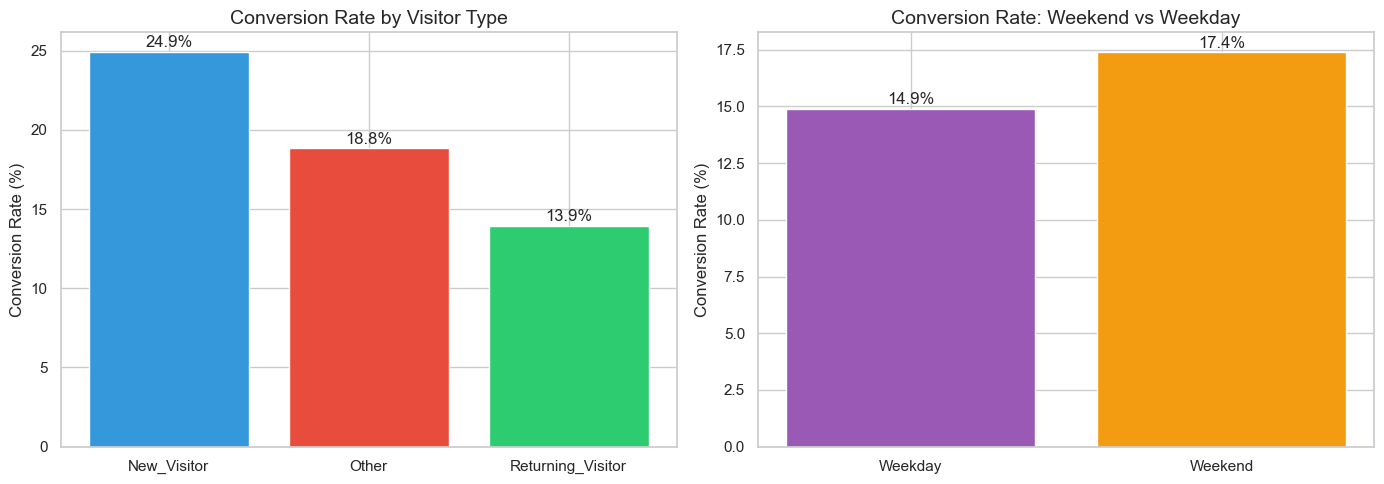

In [9]:
# Conversion by Visitor Type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

visitor_cvr = df.groupby('VisitorType')['Revenue'].agg(['mean', 'count']).reset_index()
visitor_cvr.columns = ['VisitorType', 'ConvRate', 'Count']

axes[0].bar(visitor_cvr['VisitorType'], visitor_cvr['ConvRate'] * 100,
            color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='white')
axes[0].set_title('Conversion Rate by Visitor Type')
axes[0].set_ylabel('Conversion Rate (%)')
for i, (_, row) in enumerate(visitor_cvr.iterrows()):
    axes[0].text(i, row['ConvRate'] * 100 + 0.3, f'{row["ConvRate"]*100:.1f}%', ha='center')

# Weekend vs Weekday
weekend_cvr = df.groupby('Weekend')['Revenue'].mean() * 100
axes[1].bar(['Weekday', 'Weekend'], weekend_cvr.values,
            color=['#9b59b6', '#f39c12'], edgecolor='white')
axes[1].set_title('Conversion Rate: Weekend vs Weekday')
axes[1].set_ylabel('Conversion Rate (%)')
for i, v in enumerate(weekend_cvr.values):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.savefig('../data/processed/fig_visitor_weekend.png', dpi=150, bbox_inches='tight')
plt.show()

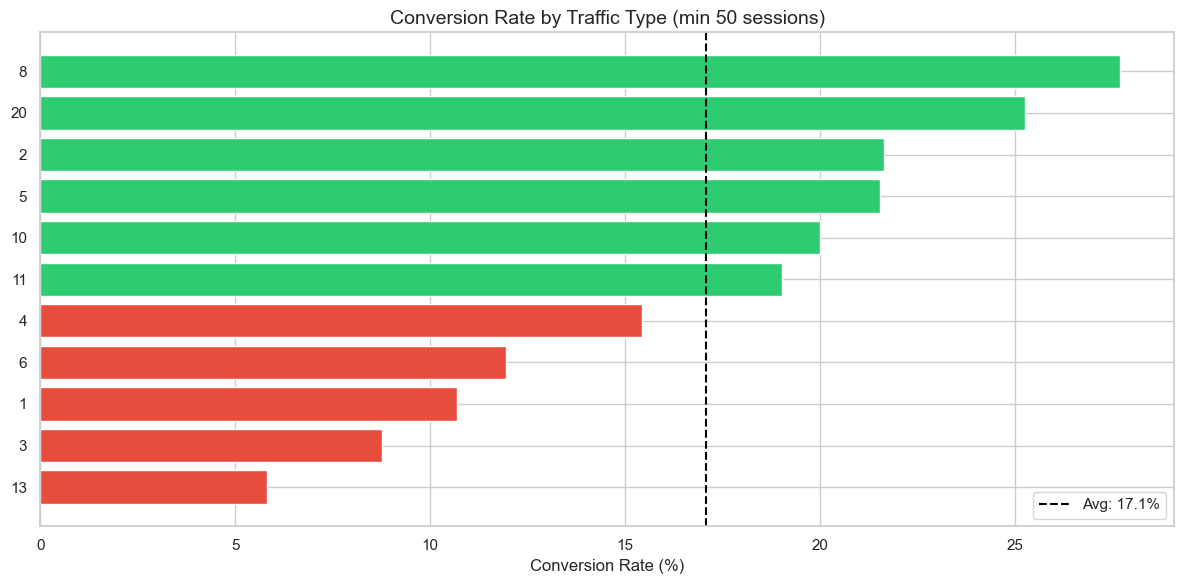


Top 5 converting traffic types:
    TrafficType  sessions  conversion_rate
7             8       343         0.276968
19           20       198         0.252525
1             2      3913         0.216458
4             5       260         0.215385
9            10       450         0.200000


In [10]:
# Conversion by Traffic Type (top 10)
traffic_cvr = df.groupby('TrafficType').agg(
    sessions=('Revenue', 'count'),
    conversion_rate=('Revenue', 'mean')
).reset_index()
traffic_cvr = traffic_cvr[traffic_cvr['sessions'] >= 50].sort_values('conversion_rate', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#2ecc71' if r > traffic_cvr['conversion_rate'].mean() else '#e74c3c'
          for r in traffic_cvr['conversion_rate']]
bars = ax.barh(traffic_cvr['TrafficType'].astype(str), traffic_cvr['conversion_rate'] * 100,
               color=colors, edgecolor='white')
ax.axvline(traffic_cvr['conversion_rate'].mean() * 100, color='black', linestyle='--',
           label=f'Avg: {traffic_cvr["conversion_rate"].mean()*100:.1f}%')
ax.set_xlabel('Conversion Rate (%)')
ax.set_title('Conversion Rate by Traffic Type (min 50 sessions)')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/fig_traffic_conversion.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 converting traffic types:')
print(traffic_cvr.sort_values('conversion_rate', ascending=False).head())

## 5. Page Values & Bounce Rate Analysis

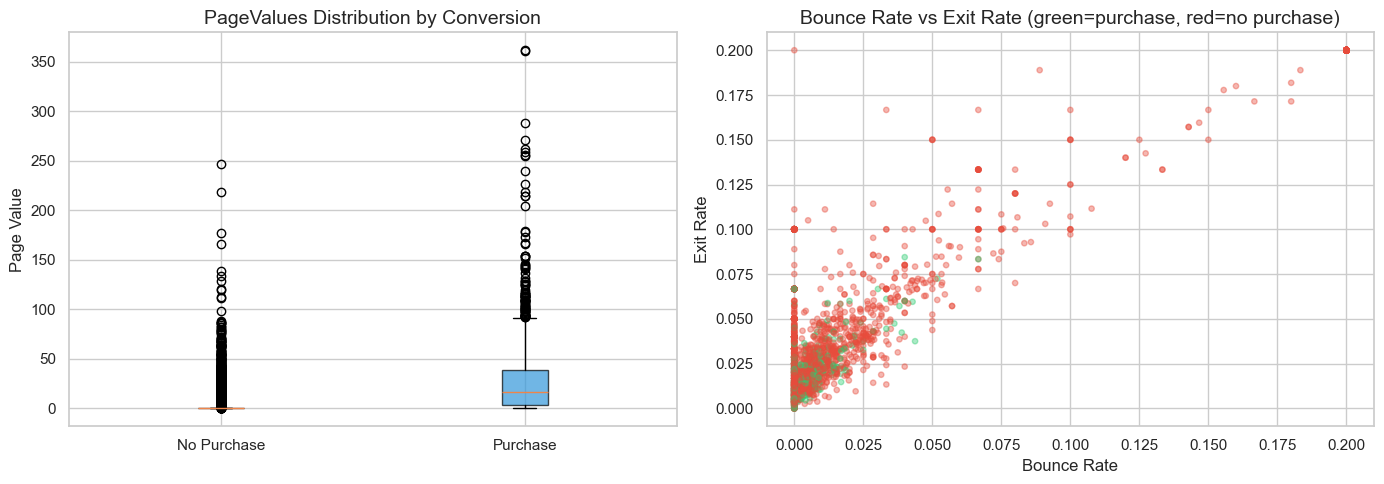


Median PageValues — Converters: 16.76 | Non-converters: 0.00


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PageValues by conversion (log scale for readability)
converted = df[df['Revenue'] == True]['PageValues']
not_converted = df[df['Revenue'] == False]['PageValues']

axes[0].boxplot([not_converted, converted], labels=['No Purchase', 'Purchase'],
                patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.7))
axes[0].set_title('PageValues Distribution by Conversion')
axes[0].set_ylabel('Page Value')

# Bounce rate vs Exit rate scatter
sample = df.sample(2000, random_state=42)
colors_scatter = ['#2ecc71' if r else '#e74c3c' for r in sample['Revenue']]
axes[1].scatter(sample['BounceRates'], sample['ExitRates'],
                c=colors_scatter, alpha=0.4, s=15)
axes[1].set_xlabel('Bounce Rate')
axes[1].set_ylabel('Exit Rate')
axes[1].set_title('Bounce Rate vs Exit Rate (green=purchase, red=no purchase)')

plt.tight_layout()
plt.savefig('../data/processed/fig_pagevalue_bounce.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nMedian PageValues — Converters: {converted.median():.2f} | Non-converters: {not_converted.median():.2f}')

## 6. Correlation Heatmap

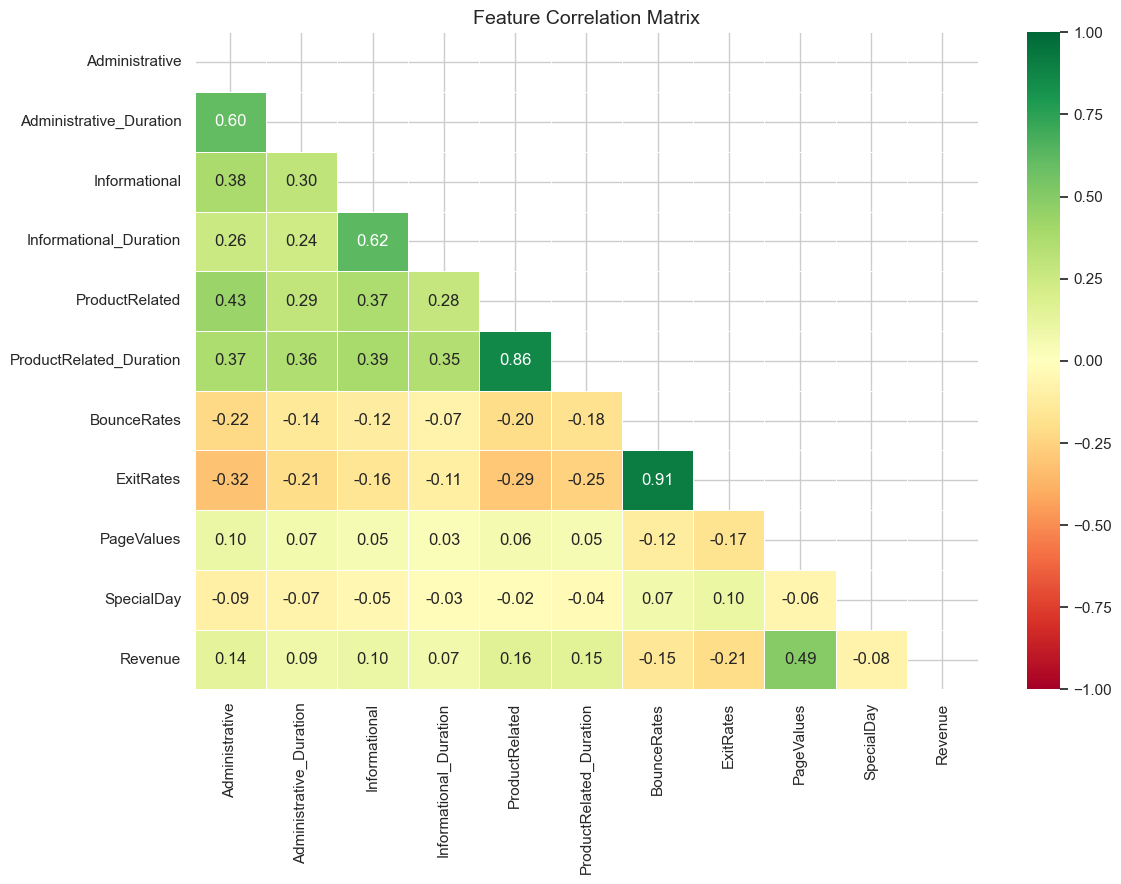


Correlation with Revenue (sorted):
PageValues                 0.492569
ProductRelated             0.158538
ProductRelated_Duration    0.152373
Administrative             0.138917
Informational              0.095200
Administrative_Duration    0.093587
Informational_Duration     0.070345
SpecialDay                -0.082305
BounceRates               -0.150673
ExitRates                 -0.207071
Name: Revenue, dtype: float64


In [12]:
df_corr = df[num_cols + ['Revenue']].copy()
df_corr['Revenue'] = df_corr['Revenue'].astype(int)

corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('../data/processed/fig_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCorrelation with Revenue (sorted):')
print(corr_matrix['Revenue'].sort_values(ascending=False).drop('Revenue'))

## 7. Key EDA Findings Summary

In [13]:
print('=' * 60)
print('KEY EDA FINDINGS')
print('=' * 60)

overall_cvr = df['Revenue'].mean() * 100
print(f'\n1. CLASS IMBALANCE: {overall_cvr:.1f}% conversion rate ({df["Revenue"].sum()} purchases out of {len(df)} sessions)')
print('   → Model must use SMOTE or class weights')

nov_cvr = df[df['Month'] == 'Nov']['Revenue'].mean() * 100
feb_cvr = df[df['Month'] == 'Feb']['Revenue'].mean() * 100 if 'Feb' in df['Month'].values else 0
print(f'\n2. SEASONALITY: November has {nov_cvr:.1f}% conversion rate (holiday shopping spike)')

ret_cvr = df[df['VisitorType'] == 'Returning_Visitor']['Revenue'].mean() * 100
new_cvr = df[df['VisitorType'] == 'New_Visitor']['Revenue'].mean() * 100
print(f'\n3. VISITOR TYPE: Returning visitors convert at {ret_cvr:.1f}% vs New visitors at {new_cvr:.1f}%')

pv_corr = df_corr.corr()['Revenue']['PageValues']
print(f'\n4. PAGE VALUES: Strongest correlation with Revenue (r={pv_corr:.3f})')
print('   → Sessions with high page values are strong conversion signals')

zero_pv = (df['PageValues'] == 0).mean() * 100
print(f'\n5. PAGE VALUE SKEW: {zero_pv:.1f}% of sessions have PageValues = 0 (non-commercial pages)')

print('\n6. BOUNCE & EXIT RATES: High correlation with each other (0.91)')
print('   → Near-zero bounce rate sessions strongly associated with conversion')

print('=' * 60)

KEY EDA FINDINGS

1. CLASS IMBALANCE: 15.5% conversion rate (1908 purchases out of 12330 sessions)
   → Model must use SMOTE or class weights

2. SEASONALITY: November has 25.4% conversion rate (holiday shopping spike)

3. VISITOR TYPE: Returning visitors convert at 13.9% vs New visitors at 24.9%

4. PAGE VALUES: Strongest correlation with Revenue (r=0.493)
   → Sessions with high page values are strong conversion signals

5. PAGE VALUE SKEW: 77.9% of sessions have PageValues = 0 (non-commercial pages)

6. BOUNCE & EXIT RATES: High correlation with each other (0.91)
   → Near-zero bounce rate sessions strongly associated with conversion


In [14]:
# Save cleaned data snapshot
df.to_csv('../data/processed/online_shoppers_clean.csv', index=False)
print('Saved cleaned dataset to ../data/processed/online_shoppers_clean.csv')

Saved cleaned dataset to ../data/processed/online_shoppers_clean.csv
